In [1]:
from calendar import weekday
import datetime as dt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels as sm
import sklearn

In [2]:
df = pd.read_csv("parsittuData.csv")
df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])
df["WeekDay"] = df["TimeStamp"].dt.day_name()
df["Date"] = df["TimeStamp"].apply(lambda x: x.date())


<Axes: xlabel='TimeStamp', ylabel='Electricity consumption in Finland'>

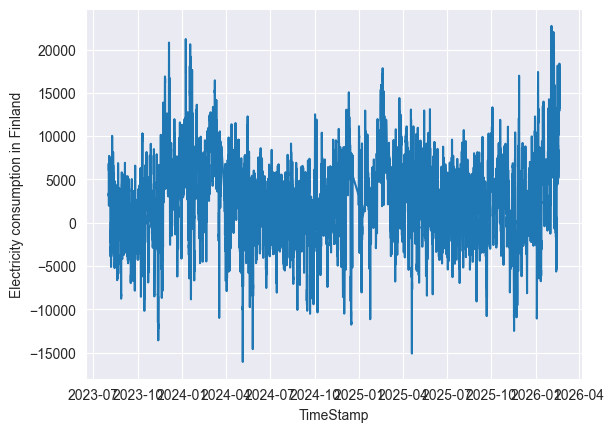

In [3]:
df["Weekend"] = df["WeekDay"]=="Sunday"
df.loc[df["WeekDay"]=="Saturday", "Weekend"]=True
df["Month"] = df["Date"].apply(lambda x: x.month)



df.head()


y=df["Electricity consumption in Finland"]
X = df[["Mean Hel","Mean Rov", "Mean Tam", "Weekend"]]
lm = sklearn.linear_model.LinearRegression(fit_intercept=False)
lm.fit(X,y)
predicted = lm.predict(X)
errors = y-predicted
sns.lineplot(y= errors, x = df["TimeStamp"])





,TimeStamp,Mean Hel,Max Hel,Min Hel,Mean Rov,Max Rov,Min Rov,Mean Tam,Max Tam,Min Tam,Electricity consumption in Finland,WeekDay,Date,Weekend,Month
0,2023-08-01 15:00:00,17.1,17.4,16.8,20.7,21.3,20.1,16.3,16.9,16.0,7794.000,Tuesday,2023-08-01,False,8
1,2023-08-01 16:00:00,17.1,17.4,16.7,21.6,22.3,20.8,16.5,16.8,15.9,7830.000,Tuesday,2023-08-01,False,8
2,2023-08-01 17:00:00,17.1,17.3,16.7,20.9,22.3,15.7,16.1,17.2,15.5,7789.000,Tuesday,2023-08-01,False,8
3,2023-08-01 18:00:00,16.8,17.1,16.4,15.6,16.3,14.9,17.5,17.7,17.2,7619.500,Tuesday,2023-08-01,False,8
4,2023-08-01 19:00:00,16.6,17.2,16.3,16.4,16.9,16.2,16.9,17.2,16.7,7493.000,Tuesday,2023-08-01,False,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21299,2026-02-18 23:00:00,-11.3,-11.1,-11.5,-10.9,-10.0,-11.7,-12.8,-10.6,-14.6,12378.525,Wednesday,2026-02-18,False,2
21300,2026-02-19 00:00:00,-11.4,-11.2,-11.5,-12.2,-11.7,-12.6,-13.2,-12.1,-13.8,12269.550,Thursday,2026-02-19,False,2
21301,2026-02-19 01:00:00,-11.3,-11.2,-11.3,-12.0,-11.7,-12.3,-14.0,-13.4,-14.7,12176.125,Thursday,2026-02-19,False,2
21302,2026-02-19 02:00:00,-11.3,-11.2,-11.5,-11.6,-11.3,-11.7,-14.6,-14.2,-15.1,12217.050,Thursday,2026-02-19,False,2


In [ ]:
#model with weekly and yearly season and trend

